In [88]:
import pandas as pd
from prophet import Prophet
from DBD_1 import load_diesel
from DBD_1 import load_petrol
from DBD_1 import print_feature_dist
from DBD_1 import print_feature_vs_y_line_graphs
import numpy as np
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from matplotlib import pyplot as plt


## Load Data

In [78]:
diesel_df = load_diesel()
diesel_df["Total_Production_Lag1"] = diesel_df["Total_Production"].shift(1)
petrol_df = load_petrol()
petrol_df["Total_Production_Lag1"] = petrol_df["Total_Production"].shift(1)
diesel_df.head()

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


,Date,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,Brent_LastWeekStd,...,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production,Total_Production_Lag1
0,2011-01-01,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,0.932393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764,NaN
1,2011-02-01,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,4.277731,...,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099,68537.7764
2,2011-03-01,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,0.556729,...,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421,68700.0099
3,2011-04-01,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,1.233450,...,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479,67169.5421
4,2011-05-01,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,2.422369,...,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645,67351.0479


## Feature Selection

In [ ]:

def evaluate_feature_set(df, feature_cols, target_col="Total_Fuel_Price",
                          n_windows=5, min_train_months=24):
    """
    Rolling walk-forward evaluation of a Prophet regressor set.
    Test window size is derived from TEST_RATIO applied to the usable data length;
    forecast target is shifted by FORECAST_HORIZON months (global).
    """
    prophet_df = df[["Date", target_col] + feature_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    # Target is shifted to prevent data leakage - IE model can't view data from after that month
    prophet_df["y"] = prophet_df["y"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna().reset_index(drop=True)

    n_total = len(prophet_df)
    if n_total < min_train_months + FORECAST_HORIZON:
        return np.nan

    # derive test window size from TEST_RATIO, applied to the full usable series
    window_size = max(FORECAST_HORIZON, int(round(n_total * TEST_RATIO / n_windows)))

    rmses = []
    for i in range(n_windows):
        end = n_total - i * window_size
        start = end - window_size
        if start < min_train_months:
            break

        train_fold = prophet_df.iloc[:start]
        test_fold = prophet_df.iloc[start:end]
        if len(test_fold) == 0:
            continue

        try:
            m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
            for col in feature_cols:
                m.add_regressor(col)
            m.fit(train_fold)

            fc = m.predict(test_fold[["ds"] + feature_cols])
            rmse = root_mean_squared_error(test_fold["y"], fc["yhat"])
            rmses.append(rmse)
        except Exception:
            continue

    return np.mean(rmses) if rmses else np.nan


def select_prophet_features(df, candidate_features, target_col="Total_Fuel_Price",
                             n_windows=5, min_train_months=24, max_features=10):
    remaining = list(candidate_features)
    selected = []

    best_rmse = evaluate_feature_set(df, selected, target_col, n_windows, min_train_months)

    improved = True
    while improved and remaining and len(selected) < max_features:
        improved = False
        scores = {
            feat: evaluate_feature_set(df, selected + [feat], target_col, n_windows, min_train_months)
            for feat in remaining
        }

        best_feat = min(scores, key=lambda k: scores[k] if not np.isnan(scores[k]) else np.inf)
        best_candidate_rmse = scores[best_feat]

        if not np.isnan(best_candidate_rmse) and best_candidate_rmse < best_rmse:
            selected.append(best_feat)
            remaining.remove(best_feat)
            best_rmse = best_candidate_rmse
            improved = True

    return selected, best_rmse

In [94]:
# ---- Global configuration ----
TRAIN_RATIO = 0.8        # proportion of usable data used for training in each fold
TEST_RATIO = 0.2         # proportion used for testing (must sum to 1 with TRAIN_RATIO)
FORECAST_HORIZON = 3     # months ahead to forecast (e.g. 1 = one-month-ahead, 3 = three-months-ahead)

assert abs(TRAIN_RATIO + TEST_RATIO - 1.0) < 1e-9, "TRAIN_RATIO + TEST_RATIO must equal 1"

exclude_cols = ["Date", "Total_Production"]
candidate_features = [c for c in diesel_df.columns if c not in exclude_cols]

selected_diesel_features, final_rmse = select_prophet_features(diesel_df, candidate_features)

print(selected_diesel_features)
print(f"Final mean RMSE: {final_rmse:.4f}")

12:45:24 - cmdstanpy - INFO - Chain [1] start processing
12:45:24 - cmdstanpy - INFO - Chain [1] done processing
12:45:24 - cmdstanpy - INFO - Chain [1] start processing
12:45:24 - cmdstanpy - INFO - Chain [1] done processing
12:45:24 - cmdstanpy - INFO - Chain [1] start processing
12:45:24 - cmdstanpy - INFO - Chain [1] done processing
12:45:24 - cmdstanpy - INFO - Chain [1] start processing
12:45:24 - cmdstanpy - INFO - Chain [1] done processing
12:45:24 - cmdstanpy - INFO - Chain [1] start processing
12:45:24 - cmdstanpy - INFO - Chain [1] done processing
12:45:24 - cmdstanpy - INFO - Chain [1] start processing
12:45:24 - cmdstanpy - INFO - Chain [1] done processing
12:45:24 - cmdstanpy - INFO - Chain [1] start processing
12:45:24 - cmdstanpy - INFO - Chain [1] done processing
12:45:24 - cmdstanpy - INFO - Chain [1] start processing
12:45:24 - cmdstanpy - INFO - Chain [1] done processing
12:45:24 - cmdstanpy - INFO - Chain [1] start processing
12:45:24 - cmdstanpy - INFO - Chain [1]

['BFP', 'GSCPI_Lag12', 'GPR_Lag6', 'BFP_Delta_Lag1', 'Brent_LastWeekStd', 'GECON_Lag3', 'USDZAR_Delta_Lag1']
Final mean RMSE: 252.2691


In [86]:
print_feature_dist(prophet_df)
print_feature_vs_y_line_graphs(prophet_df)

## Model evaluation

In [89]:
def run_prophet_model(df, feature_cols, target_col="Total_Fuel_Price",
                       include_2026=True, plot=True):
    """
    Fits and evaluates a single Prophet model on the given feature set,
    using the global TRAIN_RATIO / TEST_RATIO / FORECAST_HORIZON.

    Parameters
    ----------
    df           : master dataframe (e.g. master_diesel_df)
    feature_cols : list of selected regressor column names
    target_col   : target price column
    include_2026 : if False, drops all rows from 2026 onward before modelling
    plot         : if True, shows an actual vs predicted plot for the test set

    Returns
    -------
    dict with rmse, mae, r2, and the fitted model/forecast objects
    """
    feature_cols = [c for c in feature_cols if c not in ("Date", target_col)]

    data = df.copy()
    if not include_2026:
        data = data[data["Date"] < "2026-01-01"]

    prophet_df = data[["Date", target_col] + feature_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    # Only the target is shifted forward — features stay at row t
    prophet_df["y"] = prophet_df["y"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna().reset_index(drop=True)

    n_total = len(prophet_df)
    split_idx = int(round(n_total * TRAIN_RATIO))

    train_df = prophet_df.iloc[:split_idx]
    test_df = prophet_df.iloc[split_idx:]

    if len(test_df) == 0:
        raise ValueError("Test set is empty — check TRAIN_RATIO/TEST_RATIO and data length.")

    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    for col in feature_cols:
        model.add_regressor(col)
    model.fit(train_df)

    forecast = model.predict(test_df[["ds"] + feature_cols])

    y_true = test_df["y"].values
    y_pred = forecast["yhat"].values

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"include_2026={include_2026} | horizon={FORECAST_HORIZON}m | "
          f"train={len(train_df)} rows, test={len(test_df)} rows")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")

    if plot:
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(test_df["ds"], y_true, label="Actual", marker="o")
        ax.plot(test_df["ds"], y_pred, label="Predicted", marker="o")
        ax.fill_between(test_df["ds"], forecast["yhat_lower"], forecast["yhat_upper"], alpha=0.2)
        ax.legend()
        ax.set_title(f"Prophet — {target_col} ({FORECAST_HORIZON}m ahead, include_2026={include_2026})")
        plt.tight_layout()
        plt.show()

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "model": model,
        "forecast": forecast,
        "train_df": train_df,
        "test_df": test_df,
    }

12:47:33 - cmdstanpy - INFO - Chain [1] start processing


12:47:33 - cmdstanpy - INFO - Chain [1] done processing


include_2026=True | horizon=3m | train=138 rows, test=34 rows
RMSE: 318.1481
MAE:  223.8094
R2:   -0.0349


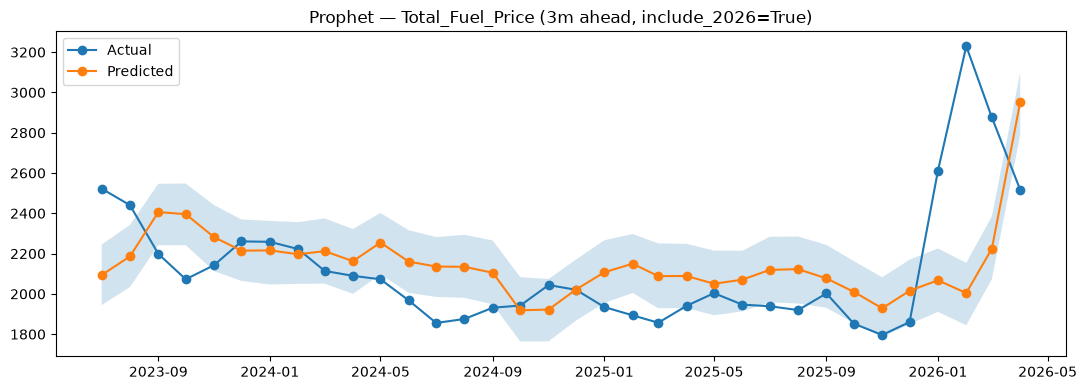

12:47:33 - cmdstanpy - INFO - Chain [1] start processing
12:47:33 - cmdstanpy - INFO - Chain [1] done processing


include_2026=False | horizon=3m | train=132 rows, test=33 rows
RMSE: 315.6898
MAE:  294.7189
R2:   -2.8608


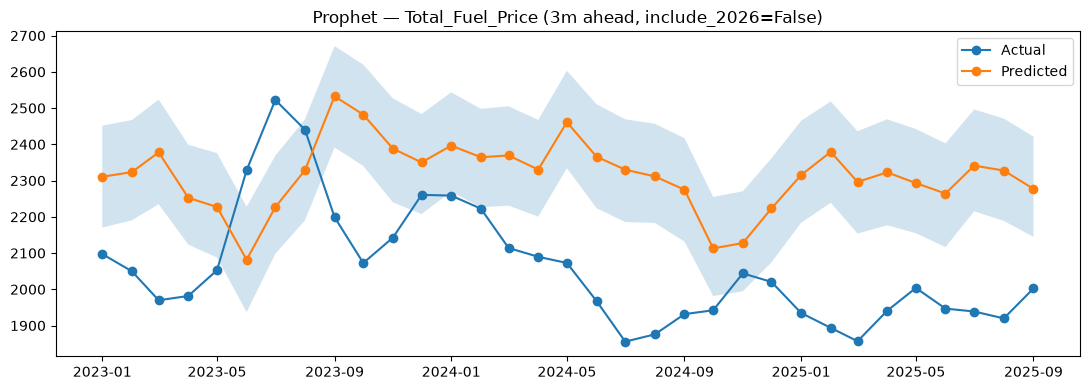

In [95]:
results_with_2026 = run_prophet_model(diesel_df, selected_diesel_features, include_2026=True)
results_no_2026 = run_prophet_model(diesel_df, selected_diesel_features, include_2026=False)

Current findings:
====================================================================
| Horizon | 2026 included | Training:Test Ratio | RMSE | MAE | R^2 |
| 1 | True | 80:20 | 108.2863 |77.5326 | 0.8748 |
| 1 | False | 80:20 | 80.5009 | 70.9225 | 0.7393 |
| 2 | True | 80:20 | 213.3201 | 159.6703 | 0.5268 |
| 2 | False | 80:20 | 210.5201| 197.9988 | -0.7169 |

RMSE: 210.5201
MAE:  197.9988
R2:   -0.7169